# Data Cleaning and Exploratory Analysis

This notebook inspects the processed CCLE/DepMap expression matrix, TP53 labels, metadata, and EDA outputs.

In [1]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
pd.set_option("display.max_columns", 30)

## Load Processed Data

In [2]:
X = pd.read_csv("data/processed/expression_matched.csv.gz", index_col=0)
labels = pd.read_csv("data/processed/tp53_labels.csv")
metadata = pd.read_csv("data/processed/sample_metadata.csv")

X.shape, labels.shape, metadata.shape

((1719, 19215), (1719, 4), (1719, 49))

In [3]:
labels.head()

,sample_id,tp53_mutant,mutation_type,mutation_type_collapsed
0,ACH-001113,1,Missense,Missense
1,ACH-001289,0,WT,WT
2,ACH-001339,1,Missense,Missense
3,ACH-001979,0,WT,WT
4,ACH-002438,0,WT,WT


In [4]:
metadata[[col for col in ["sample_id", "CellLineName", "OncotreeLineage", "OncotreePrimaryDisease"] if col in metadata.columns]].head()

,sample_id,CellLineName,OncotreeLineage,OncotreePrimaryDisease
0,ACH-001113,LC-1/sq-SF,Lung,Non-Small Cell Lung Cancer
1,ACH-001289,COG-AR-359,CNS/Brain,Embryonal Tumor
2,ACH-001339,Colo 794,Skin,Melanoma
3,ACH-001979,NZM11,Skin,Melanoma
4,ACH-002438,CCLF_PEDS_0026_T,Kidney,Wilms' Tumor


## Class Balance

In [5]:
pd.read_csv("reports/tables/binary_class_balance.csv")

,class,count,percentage
0,Mutant,997,57.998837
1,WT,722,42.001163


In [6]:
pd.read_csv("reports/tables/mutation_type_balance.csv")

,mutation_type,count,percentage
0,WT,722,42.001163
1,Missense,620,36.067481
2,Other,189,10.994764
3,Nonsense,113,6.573589
4,Frameshift,58,3.374055
5,In-frame indel,9,0.523560
6,Synonymous,8,0.465387


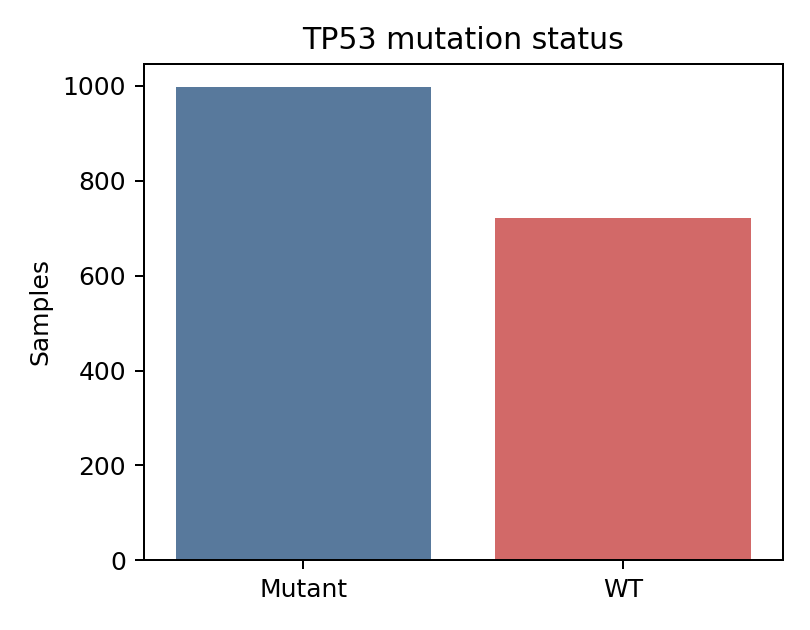

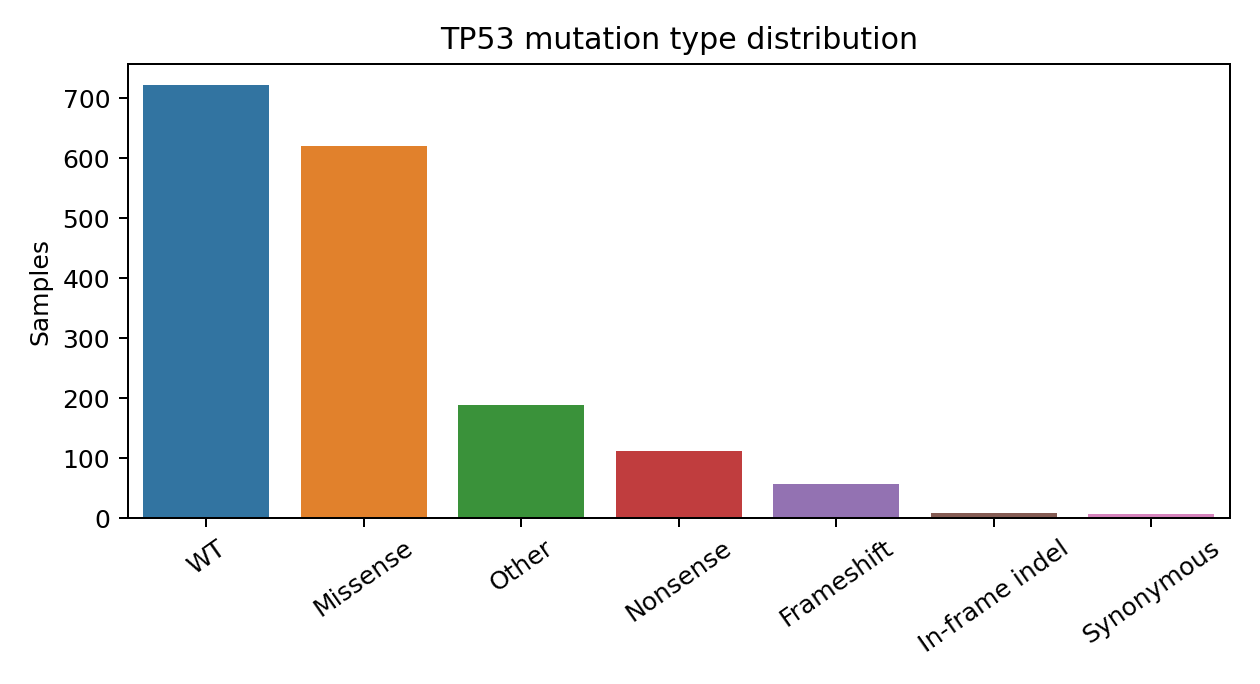

In [7]:
display(Image(filename="reports/figures/binary_class_balance.png"))
display(Image(filename="reports/figures/mutation_type_balance.png"))

## Expression Summary and PCA

In [8]:
pd.read_csv("reports/tables/expression_summary.csv")

,metric,value
0,samples,1719.000000
1,genes,19215.000000
2,missing_values,0.000000
3,mean_expression,2.670069
4,median_expression,2.415231


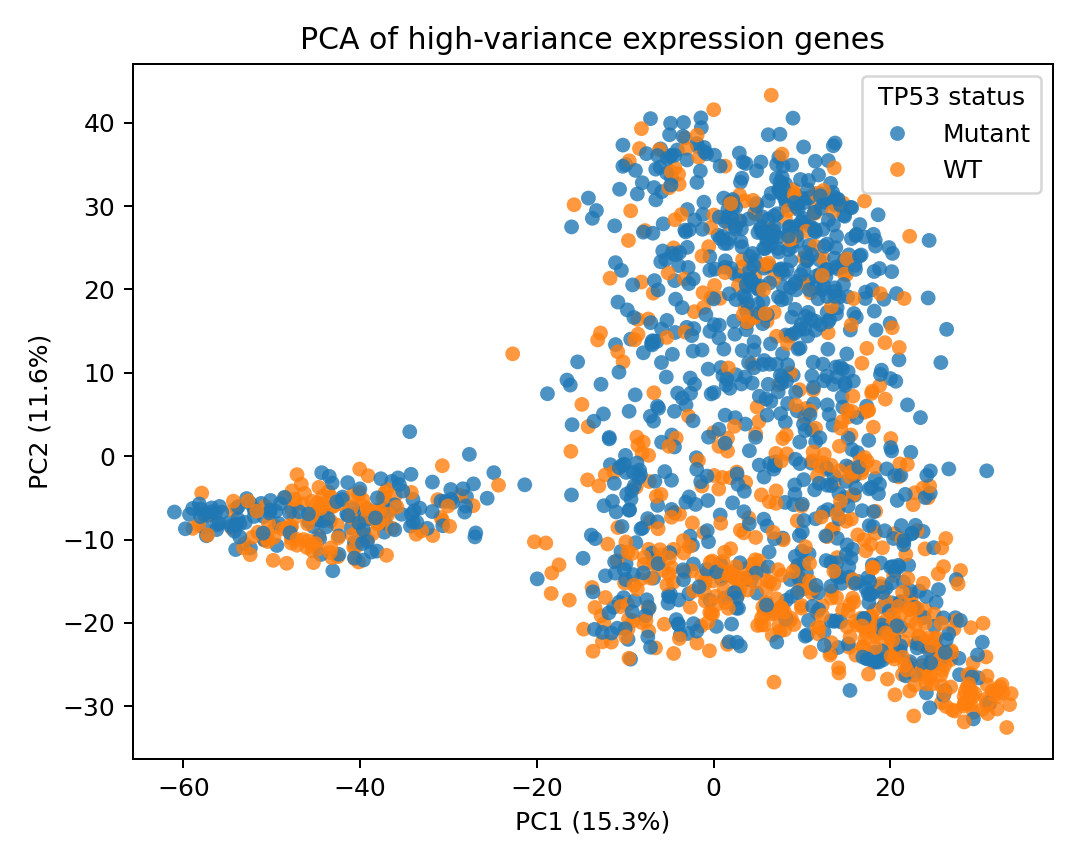

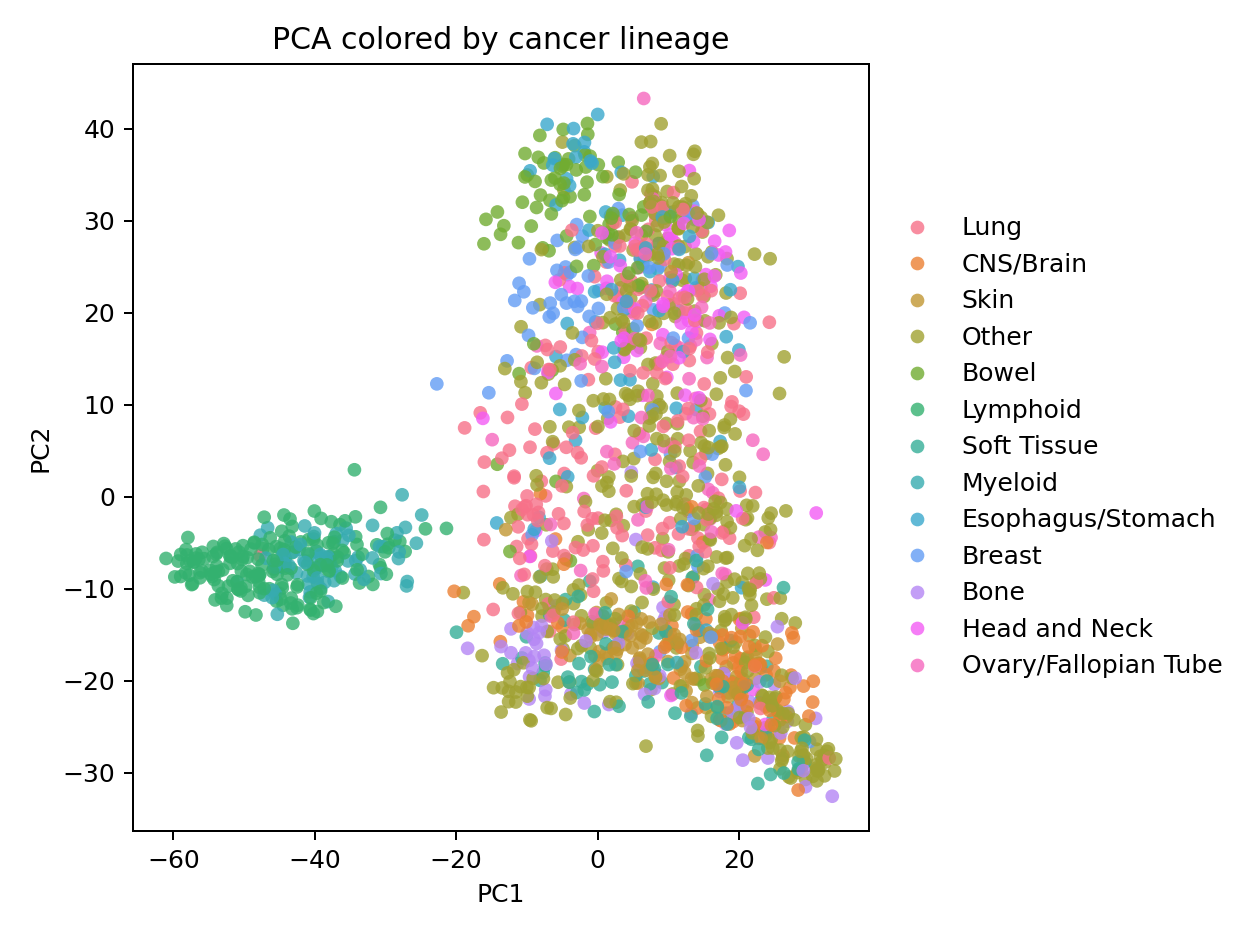

In [9]:
display(Image(filename="reports/figures/pca_tp53_status.png"))
display(Image(filename="reports/figures/pca_lineage.png"))